## Step By Step Process of Training a ML Model

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings 
warnings.filterwarnings('ignore')

df = pd.read_csv('insurance.csv')
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


this is our dataset on which we are going to train our model

## Step 1 -> EDA 

In [2]:
df.head(3)

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.90,0,yes,southwest,16884.9240
1,18,male,33.77,1,no,southeast,1725.5523
2,28,male,33.00,3,no,southeast,4449.4620


In [3]:
df.tail(3)

,age,sex,bmi,children,smoker,region,charges
1335,18,female,36.85,0,no,southeast,1629.8335
1336,21,female,25.80,0,no,southwest,2007.9450
1337,61,female,29.07,0,yes,northwest,29141.3603


In [4]:
df.shape

(1338, 7)

In [5]:
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [6]:
df.drop_duplicates(inplace=True)
df.shape

(1337, 7)

In [7]:
df.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='object')

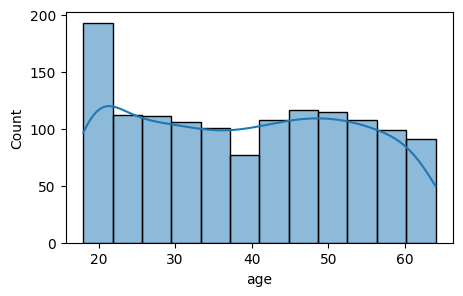

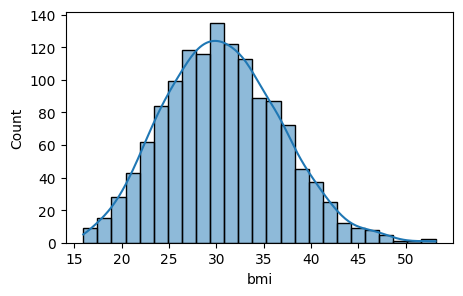

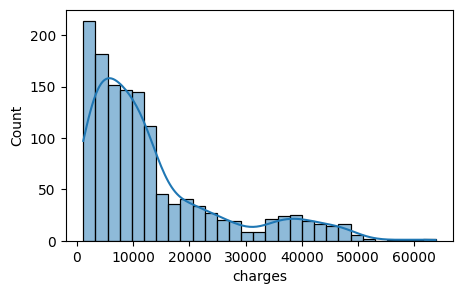

In [8]:
column = ['age', 'bmi', 'charges']

for col in column : 
    plt.figure(figsize=(5, 3))
    sns.histplot(data=df, x=col, kde=True)

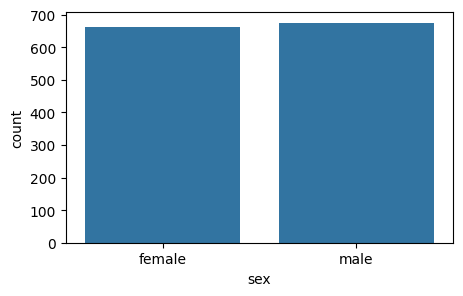

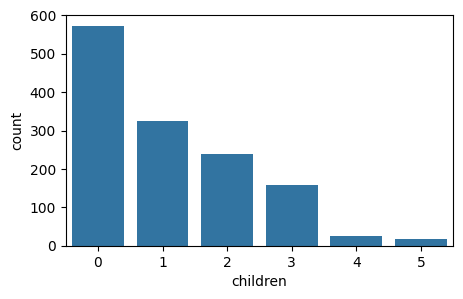

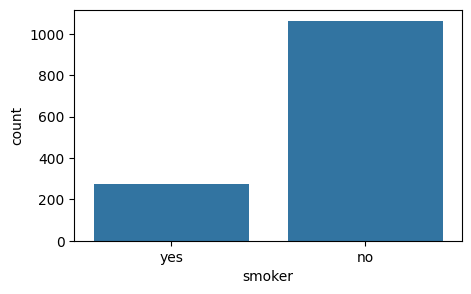

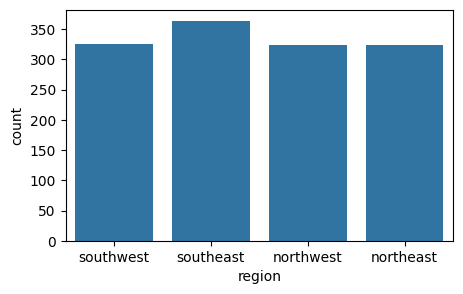

In [9]:
catCol = ['sex', 'children', 'smoker', 'region']
for col in catCol:
    plt.figure(figsize=(5, 3))
    sns.countplot(data=df, x=col)

## Step 2 -> Preprocessiong

In [10]:
df['sex'].value_counts()

sex
male      675
female    662
Name: count, dtype: int64

In [11]:
df.dtypes

age           int64
sex          object
bmi         float64
children      int64
smoker       object
region       object
charges     float64
dtype: object

In [12]:
#  Label encoding the sex and smoker columns 
df['sex'] = df['sex'].map({"male": 0, "female": 1})
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,1,27.900,0,yes,southwest,16884.92400
1,18,0,33.770,1,no,southeast,1725.55230
2,28,0,33.000,3,no,southeast,4449.46200
3,33,0,22.705,0,no,northwest,21984.47061
4,32,0,28.880,0,no,northwest,3866.85520


In [13]:
df['smoker'] = df['smoker'].map({"no": 0, "yes": 1})
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,1,27.900,0,1,southwest,16884.92400
1,18,0,33.770,1,0,southeast,1725.55230
2,28,0,33.000,3,0,southeast,4449.46200
3,33,0,22.705,0,0,northwest,21984.47061
4,32,0,28.880,0,0,northwest,3866.85520


In [14]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,1,27.900,0,1,southwest,16884.92400
1,18,0,33.770,1,0,southeast,1725.55230
2,28,0,33.000,3,0,southeast,4449.46200
3,33,0,22.705,0,0,northwest,21984.47061
4,32,0,28.880,0,0,northwest,3866.85520


In [15]:
df.rename(columns=({'sex': 'isFemale', 'smoker': 'isSmoker'}), inplace=True)
df.head()

,age,isFemale,bmi,children,isSmoker,region,charges
0,19,1,27.900,0,1,southwest,16884.92400
1,18,0,33.770,1,0,southeast,1725.55230
2,28,0,33.000,3,0,southeast,4449.46200
3,33,0,22.705,0,0,northwest,21984.47061
4,32,0,28.880,0,0,northwest,3866.85520


## One hot encoding for childrend and regions

In [16]:
df['region'].value_counts()

region
southeast    364
southwest    325
northwest    324
northeast    324
Name: count, dtype: int64

In [17]:
df = pd.get_dummies(df, columns=['region'], drop_first=True)
df.head()


,age,isFemale,bmi,children,isSmoker,charges,region_northwest,region_southeast,region_southwest
0,19,1,27.900,0,1,16884.92400,False,False,True
1,18,0,33.770,1,0,1725.55230,False,True,False
2,28,0,33.000,3,0,4449.46200,False,True,False
3,33,0,22.705,0,0,21984.47061,True,False,False
4,32,0,28.880,0,0,3866.85520,True,False,False


In [18]:
df = df.astype(int)
df.head()

,age,isFemale,bmi,children,isSmoker,charges,region_northwest,region_southeast,region_southwest
0,19,1,27,0,1,16884,0,0,1
1,18,0,33,1,0,1725,0,1,0
2,28,0,33,3,0,4449,0,1,0
3,33,0,22,0,0,21984,1,0,0
4,32,0,28,0,0,3866,1,0,0


## Feature Engineering

#### Adding 2 features (columns) [hit and try]

In [19]:
df['bmiCateogary'] = pd.cut(df['bmi'], bins=[0, 18.5, 24.9, 29.9, float('inf')], labels=['underWeight', 'normalWeight', 'overWeight', 'obese'])
df['ageCateogary'] = pd.cut(df['age'], bins=[0, 18, 40, 60, float('inf')], labels=['child', 'young', 'infant', 'old'])

df.head()


,age,isFemale,bmi,children,isSmoker,charges,region_northwest,region_southeast,region_southwest,bmiCateogary,ageCateogary
0,19,1,27,0,1,16884,0,0,1,overWeight,young
1,18,0,33,1,0,1725,0,1,0,obese,child
2,28,0,33,3,0,4449,0,1,0,obese,young
3,33,0,22,0,0,21984,1,0,0,normalWeight,young
4,32,0,28,0,0,3866,1,0,0,overWeight,young


In [20]:
df = pd.get_dummies(df, columns=['bmiCateogary'], drop_first=True)
df = pd.get_dummies(df, columns=['ageCateogary'], drop_first=True)
df.head()

df = df.astype(int)
df.head(2)


,age,isFemale,bmi,children,isSmoker,charges,region_northwest,region_southeast,region_southwest,bmiCateogary_normalWeight,bmiCateogary_overWeight,bmiCateogary_obese,ageCateogary_young,ageCateogary_infant,ageCateogary_old
0,19,1,27,0,1,16884,0,0,1,0,1,0,1,0,0
1,18,0,33,1,0,1725,0,1,0,0,0,1,0,0,0


In [21]:
# Standard Scaling the features
from sklearn.preprocessing import StandardScaler

columns = ['bmi', 'age', 'children']
scaler = StandardScaler()

df[columns] = scaler.fit_transform(df[columns])
df.head()


,age,isFemale,bmi,children,isSmoker,charges,region_northwest,region_southeast,region_southwest,bmiCateogary_normalWeight,bmiCateogary_overWeight,bmiCateogary_obese,ageCateogary_young,ageCateogary_infant,ageCateogary_old
0,-1.440418,1,-0.517949,-0.909234,1,16884,0,0,1,0,1,0,1,0,0
1,-1.511647,0,0.462463,-0.079442,0,1725,0,1,0,0,0,1,0,0,0
2,-0.799350,0,0.462463,1.580143,0,4449,0,1,0,0,0,1,1,0,0
3,-0.443201,0,-1.334960,-0.909234,0,21984,1,0,0,1,0,0,1,0,0
4,-0.514431,0,-0.354547,-0.909234,0,3866,1,0,0,0,1,0,1,0,0


### Feature Selection 

In [22]:
#  Taking only the correlated columns which are related with the output column charges

from scipy.stats import pearsonr

columns = ['age','isFemale','bmi', 'children', 'isSmoker', 'charges','region_northwest','region_southeast','region_southwest','bmiCateogary_normalWeight','bmiCateogary_overWeight','bmiCateogary_obese','ageCateogary_young','ageCateogary_infant','ageCateogary_old']
correlations = {features: (pearsonr(df[features], df['charges']))[0]
                for features in columns}

corr_df = pd.DataFrame(list(correlations.items()), columns=['Featrues', 'relation'])
corr_df


,Featrues,relation
0,age,0.298309
1,isFemale,-0.058046
2,bmi,0.196236
3,children,0.067390
4,isSmoker,0.787234
5,charges,1.000000
6,region_northwest,-0.038695
7,region_southeast,0.073577
8,region_southwest,-0.043637
9,bmiCateogary_normalWeight,-0.104042


In [23]:
# taking Chi2 test for cateogarical data

columns = ['isFemale', 'isSmoker','region_northwest','region_southeast','region_southwest','bmiCateogary_normalWeight','bmiCateogary_overWeight','bmiCateogary_obese','ageCateogary_young','ageCateogary_infant','ageCateogary_old']


In [24]:
from scipy.stats import chi2_contingency

# taking Chi2 test for cateogarical data

columns = ['isFemale', 'isSmoker','region_northwest','region_southeast','region_southwest','bmiCateogary_normalWeight','bmiCateogary_overWeight','bmiCateogary_obese','ageCateogary_young','ageCateogary_infant','ageCateogary_old']
alpha = 0.05

df['charges_bin'] = pd.qcut(df['charges'], q=4, labels=False)
print(df['charges_bin'].head(5))
chi2_results = {}

for col in columns:
    contingency = pd.crosstab(df[col], df['charges_bin'])
    chi2_stat, p_val, _, _ = chi2_contingency(contingency)
    decision = 'Reject Null (Keep Feature)' if p_val < alpha else 'Accept Null (Drop Feature)'
    chi2_results[col] = {
        'Decision': decision
    }

chi2_df = pd.DataFrame(chi2_results).T
chi2_df

0    3
1    0
2    0
3    3
4    0
Name: charges_bin, dtype: int64


,Decision
isFemale,Reject Null (Keep Feature)
isSmoker,Reject Null (Keep Feature)
region_northwest,Accept Null (Drop Feature)
region_southeast,Reject Null (Keep Feature)
region_southwest,Accept Null (Drop Feature)
bmiCateogary_normalWeight,Accept Null (Drop Feature)
bmiCateogary_overWeight,Accept Null (Drop Feature)
bmiCateogary_obese,Reject Null (Keep Feature)
ageCateogary_young,Reject Null (Keep Feature)
ageCateogary_infant,Reject Null (Keep Feature)


In [25]:
df.head(1)

,age,isFemale,bmi,children,isSmoker,charges,region_northwest,region_southeast,region_southwest,bmiCateogary_normalWeight,bmiCateogary_overWeight,bmiCateogary_obese,ageCateogary_young,ageCateogary_infant,ageCateogary_old,charges_bin
0,-1.440418,1,-0.517949,-0.909234,1,16884,0,0,1,0,1,0,1,0,0,3


In [26]:
final_df = df[['age', 'bmi', 'children', 'isFemale','isSmoker', 'charges', 'region_southeast', 'bmiCateogary_obese', 'ageCateogary_young', 'ageCateogary_infant', 'ageCateogary_old']]
final_df.head(5)

,age,bmi,children,isFemale,isSmoker,charges,region_southeast,bmiCateogary_obese,ageCateogary_young,ageCateogary_infant,ageCateogary_old
0,-1.440418,-0.517949,-0.909234,1,1,16884,0,0,1,0,0
1,-1.511647,0.462463,-0.079442,0,0,1725,1,1,0,0,0
2,-0.799350,0.462463,1.580143,0,0,4449,1,1,1,0,0
3,-0.443201,-1.334960,-0.909234,0,0,21984,0,0,1,0,0
4,-0.514431,-0.354547,-0.909234,0,0,3866,0,0,1,0,0


## This is the final data that is ready to feeded to the model for its training

In [27]:
input_dataset = final_df.drop('charges', axis=1)
output_dataset = final_df['charges']

In [28]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(input_dataset, output_dataset, test_size=0.20, random_state=42)

### Creating a multiple Regression model to predict the charges from the test data

In [33]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()

model.fit(X=X_train, y=y_train)

y_pred = model.predict(X_test)


### Now we Check the efficiency of the model by using Performance Matrices

In [30]:
from sklearn.metrics import r2_score
r2 = r2_score(y_test, y_pred)
train_pred = model.predict(X_train)
traning_r2 = r2_score(y_train, train_pred)
traning_r2

0.7370413738497337

In [31]:
n = X_test.shape[0]
p = X_test.shape[1]

adjusted_r2 = 1 - (((1 - r2) * (n - 1)) / (n - p - 1))
adjusted_r2

0.7943768213925628

### By this we can conclude that our model is 80 percent efficient